In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install datetime

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.



  AAPL: 2511 rows
  SPY: 2511 rows
  TSLA: 2511 rows
  WM: 2511 rows
  BTC-USD: 3650 rows
  ETH-USD: 3070 rows

  MA CROSSOVER STRATEGY — FULL COMPARISON TABLE
                   B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
Ticker  MA Pair                                                                                                                                       
AAPL    MA10/30                939.93                388.04                  17.25        0.92          0.88        -38.52          -30.79       53.43
        MA100/200              939.93                278.15                  14.29        0.92          0.56        -38.52          -39.63       53.38
        MA20/50                939.93                312.89                  15.30        0.92          0.76        -38.52          -29.09       52.99
        MA25/60                939.93                304.88                  15.07  

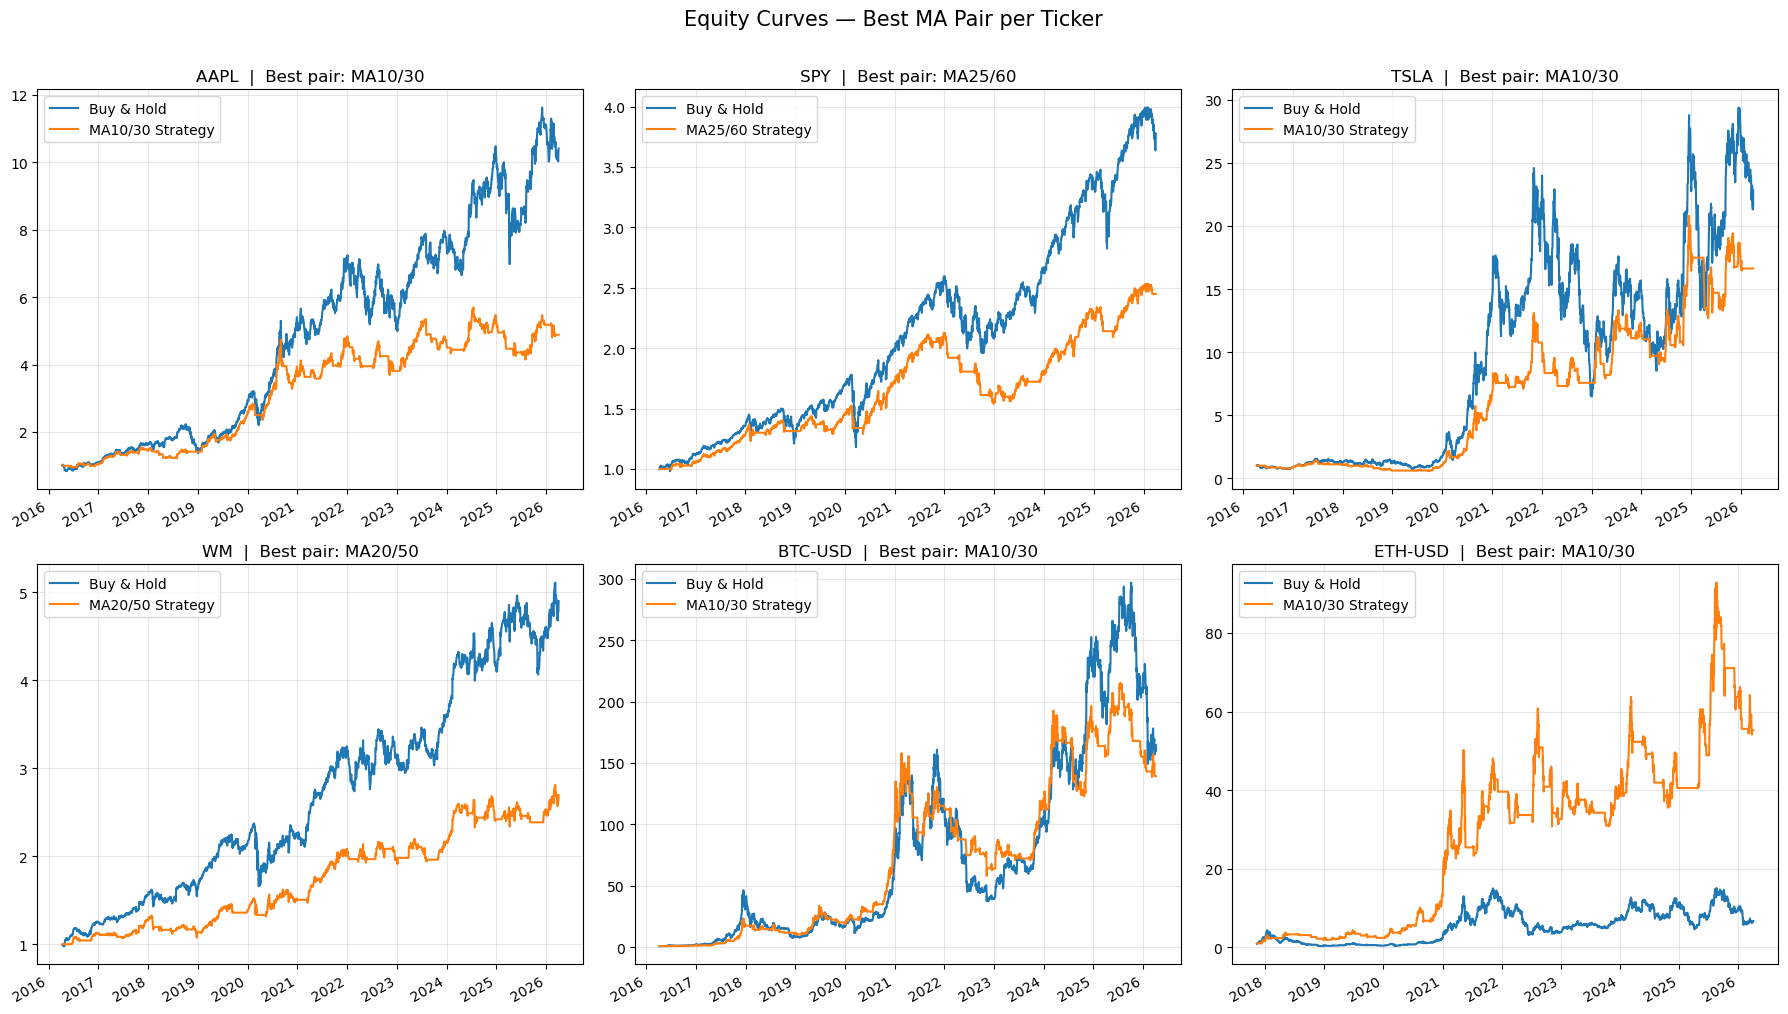


Chart saved as 'ma_best_equity_curves.png'


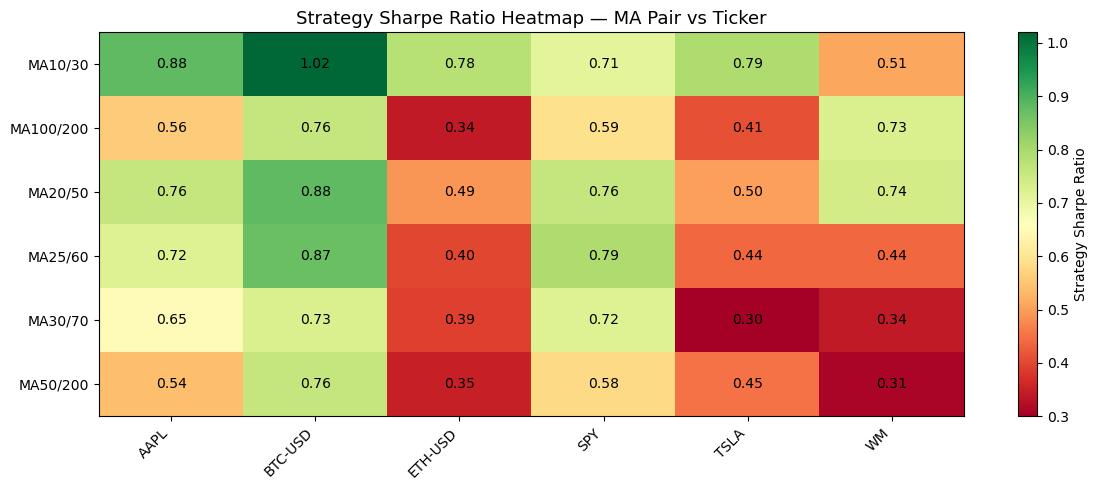

Heatmap saved as 'ma_sharpe_heatmap.png'


In [8]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
endDate   = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * 10)

stocks = ["AAPL", "SPY", "TSLA", "WM", "BTC-USD", "ETH-USD"]

# MA pairs to test: (fast window, slow window)
ma_pairs = [(10, 30), (20, 50), (25, 60), (30, 70), (50, 200), (100, 200)]

# 252 trading days/year for stocks; crypto trades 365 but 252 is fine for comparison
PERIODS_PER_YEAR = 252


# ── Helper: run a single MA crossover backtest ─────────────────────────────────
def run_backtest(price_series, fast, slow):
    df = pd.DataFrame({'price': price_series})
    df[f'MA{fast}'] = df['price'].rolling(window=fast).mean()
    df[f'MA{slow}'] = df['price'].rolling(window=slow).mean()

    # 1 when fast MA is above slow MA, else 0
    df['signal']   = (df[f'MA{fast}'] > df[f'MA{slow}']).astype(int)
    df['position'] = df['signal'].shift(1)          # act the day after signal

    df['log_returns']          = np.log(df['price'] / df['price'].shift(1))
    df['strategy_log_returns'] = df['position'] * df['log_returns']

    df['cum_market']   = np.exp(df['log_returns'].cumsum())
    df['cum_strategy'] = np.exp(df['strategy_log_returns'].cumsum())
    return df


# ── Helper: max drawdown ───────────────────────────────────────────────────────
def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    drawdown    = (cum_series - running_max) / running_max
    return drawdown.min()


# ── Helper: compute all metrics for one backtest run ──────────────────────────
def get_metrics(df):
    market_lr   = df['log_returns'].dropna()
    strategy_lr = df['strategy_log_returns'].dropna()

    total_mkt  = df['cum_market'].dropna().iloc[-1]   - 1
    total_strat = df['cum_strategy'].dropna().iloc[-1] - 1

    ann_mkt    = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat  = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1

    vol_mkt    = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat  = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)

    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan

    mdd_mkt   = max_drawdown(df['cum_market'].dropna())
    mdd_strat = max_drawdown(df['cum_strategy'].dropna())

    # win rate: % of days the strategy had a positive return
    winning_days = (strategy_lr > 0).sum()
    total_days   = (strategy_lr != 0).sum()
    win_rate     = winning_days / total_days if total_days > 0 else np.nan

    return {
        'B&H Total Return %':      round(total_mkt   * 100, 2),
        'Strat Total Return %':    round(total_strat * 100, 2),
        'Strat Annual Return %':   round(ann_strat   * 100, 2),
        'B&H Sharpe':              round(sharpe_mkt,  2),
        'Strat Sharpe':            round(sharpe_strat, 2),
        'B&H Max DD %':            round(mdd_mkt   * 100, 2),
        'Strat Max DD %':          round(mdd_strat * 100, 2),
        'Win Rate %':              round(win_rate   * 100, 2),
    }


# ── Step 1: Download price data (once per ticker) ─────────────────────────────
print("Downloading price data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=startDate, end=endDate, auto_adjust=True, progress=False)
    price_data[stock] = raw['Close'].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Run all MA pair × stock combinations ──────────────────────────────
all_results = []

for fast, slow in ma_pairs:
    for stock in stocks:
        df = run_backtest(price_data[stock], fast, slow)
        metrics = get_metrics(df)
        metrics['Ticker']  = stock
        metrics['MA Pair'] = f"MA{fast}/{slow}"
        all_results.append(metrics)


# ── Step 3: Build the comparison table ────────────────────────────────────────
results_df = (
    pd.DataFrame(all_results)
    .set_index(['Ticker', 'MA Pair'])
    .sort_index()
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

print("\n" + "=" * 100)
print("  MA CROSSOVER STRATEGY — FULL COMPARISON TABLE")
print("=" * 100)
print(results_df.to_string())


# ── Step 4: Best MA pair per stock (by Strategy Sharpe) ───────────────────────
reset = results_df.reset_index()
best_idx = reset.groupby('Ticker')['Strat Sharpe'].idxmax()
best = reset.loc[best_idx, ['Ticker', 'MA Pair', 'Strat Sharpe',
                              'Strat Total Return %', 'Strat Max DD %', 'Win Rate %']]
best = best.set_index('Ticker')

print("\n" + "=" * 100)
print("  BEST MA PAIR PER TICKER  (ranked by Strategy Sharpe Ratio)")
print("=" * 100)
print(best.to_string())


# ── Step 5: Equity curves — best MA pair per stock ────────────────────────────
best_pairs = best['MA Pair'].to_dict()   # e.g. {'AAPL': 'MA10/30', ...}

n_stocks = len(stocks)
cols = 3
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax = axes[i]
    fast_str, slow_str = best_pairs[stock].replace('MA', '').split('/')
    fast, slow = int(fast_str), int(slow_str)

    df = run_backtest(price_data[stock], fast, slow)
    df[['cum_market', 'cum_strategy']].plot(ax=ax)

    ax.set_title(f"{stock}  |  Best pair: {best_pairs[stock]}", fontsize=12)
    ax.set_xlabel('')
    ax.legend(['Buy & Hold', f"MA{fast}/{slow} Strategy"])
    ax.grid(True, alpha=0.3)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Equity Curves — Best MA Pair per Ticker", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('ma_best_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as 'ma_best_equity_curves.png'")


# ── Step 6: Strategy Sharpe heatmap (MA pair vs Ticker) ───────────────────────
sharpe_pivot = reset.pivot(index='MA Pair', columns='Ticker', values='Strat Sharpe')

fig2, ax2 = plt.subplots(figsize=(12, 5))
im = ax2.imshow(sharpe_pivot.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax2, label='Strategy Sharpe Ratio')

ax2.set_xticks(range(len(sharpe_pivot.columns)))
ax2.set_xticklabels(sharpe_pivot.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(sharpe_pivot.index)))
ax2.set_yticklabels(sharpe_pivot.index)
ax2.set_title("Strategy Sharpe Ratio Heatmap — MA Pair vs Ticker", fontsize=13)

# annotate cells
for row_i in range(len(sharpe_pivot.index)):
    for col_j in range(len(sharpe_pivot.columns)):
        val = sharpe_pivot.values[row_i, col_j]
        ax2.text(col_j, row_i, f"{val:.2f}", ha='center', va='center',
                 fontsize=10, color='black')

plt.tight_layout()
plt.savefig('ma_sharpe_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved as 'ma_sharpe_heatmap.png'")


  AAPL — All MA Pairs Compared
           B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
MA Pair                                                                                                                                       
MA10/30                939.93                388.04                  17.25        0.92          0.88        -38.52          -30.79       53.43
MA100/200              939.93                278.15                  14.29        0.92          0.56        -38.52          -39.63       53.38
MA20/50                939.93                312.89                  15.30        0.92          0.76        -38.52          -29.09       52.99
MA25/60                939.93                304.88                  15.07        0.92          0.72        -38.52          -25.48       52.75
MA30/70                939.93                279.07                  14.31        0.92          0.65        -3

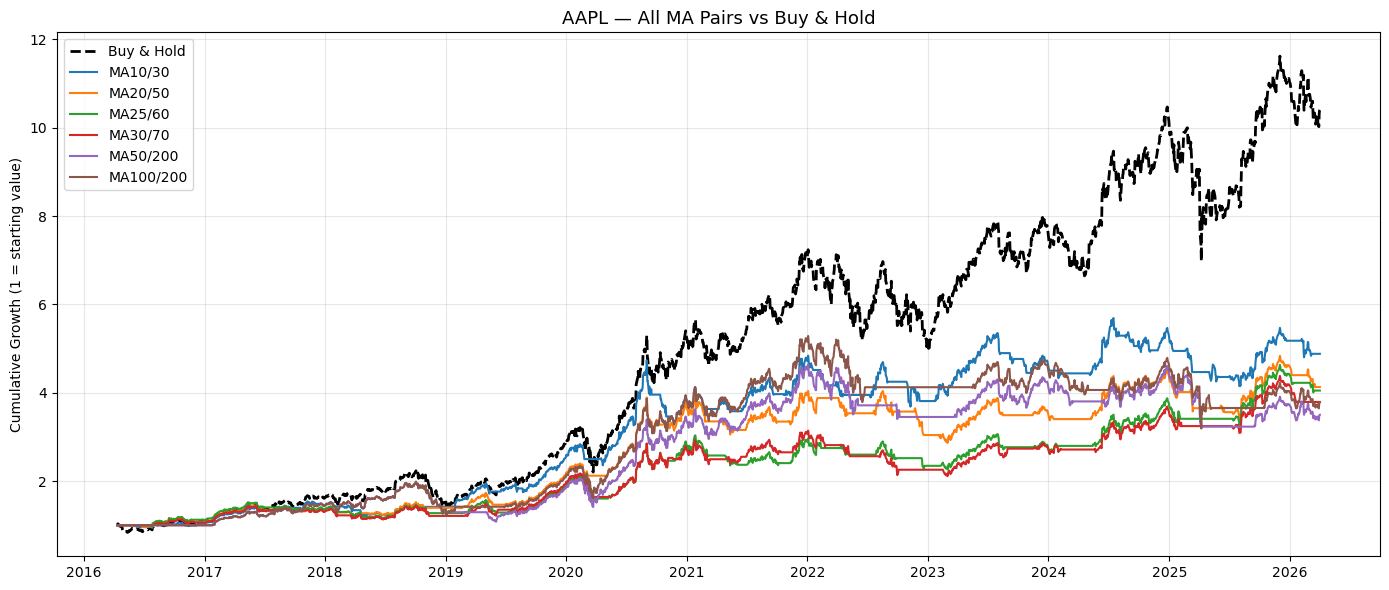

Saved: ma_all_pairs_AAPL.png



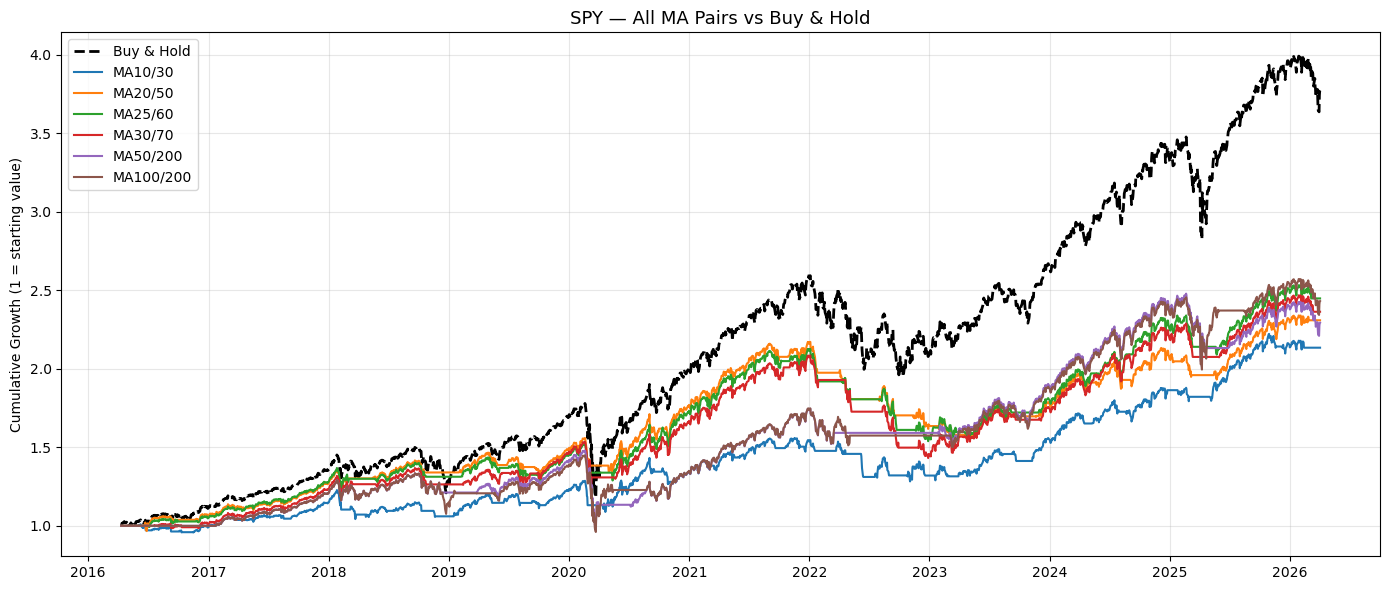

Saved: ma_all_pairs_SPY.png



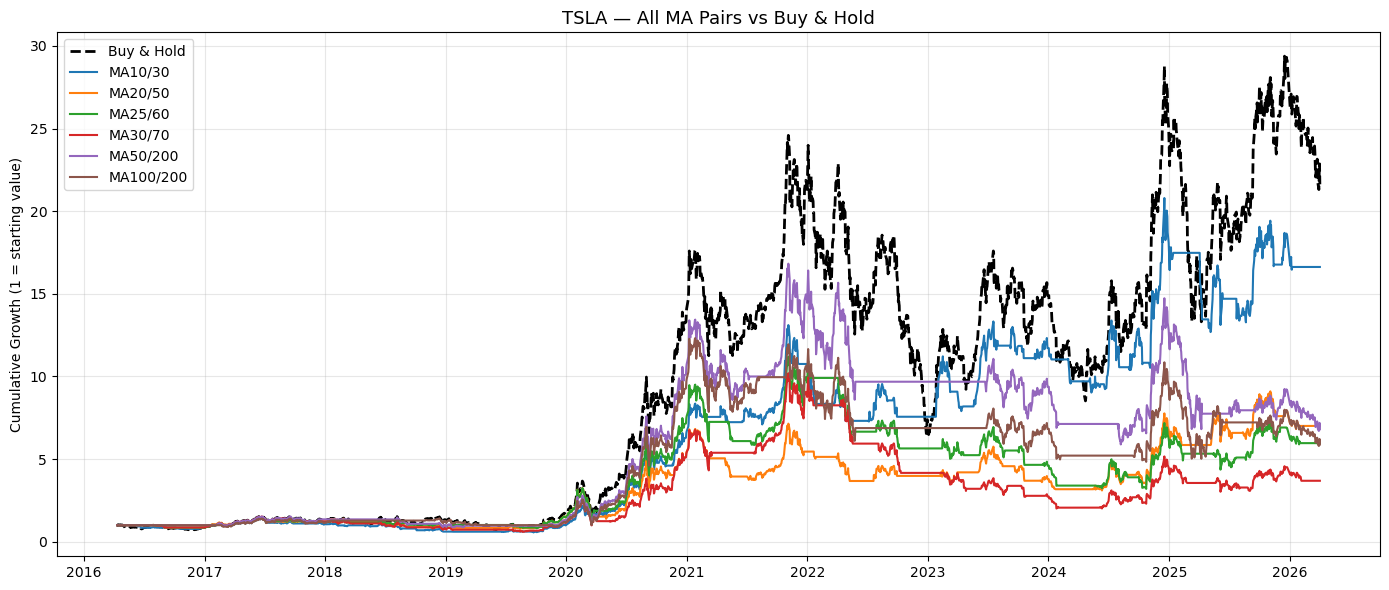

Saved: ma_all_pairs_TSLA.png



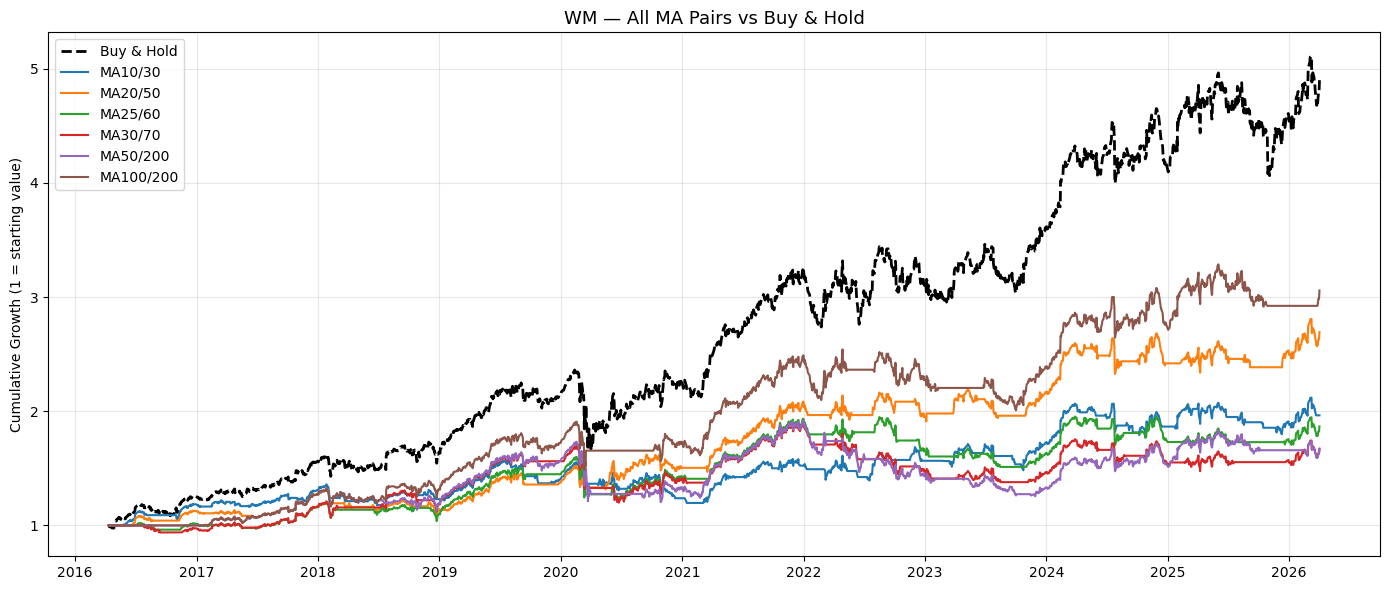

Saved: ma_all_pairs_WM.png



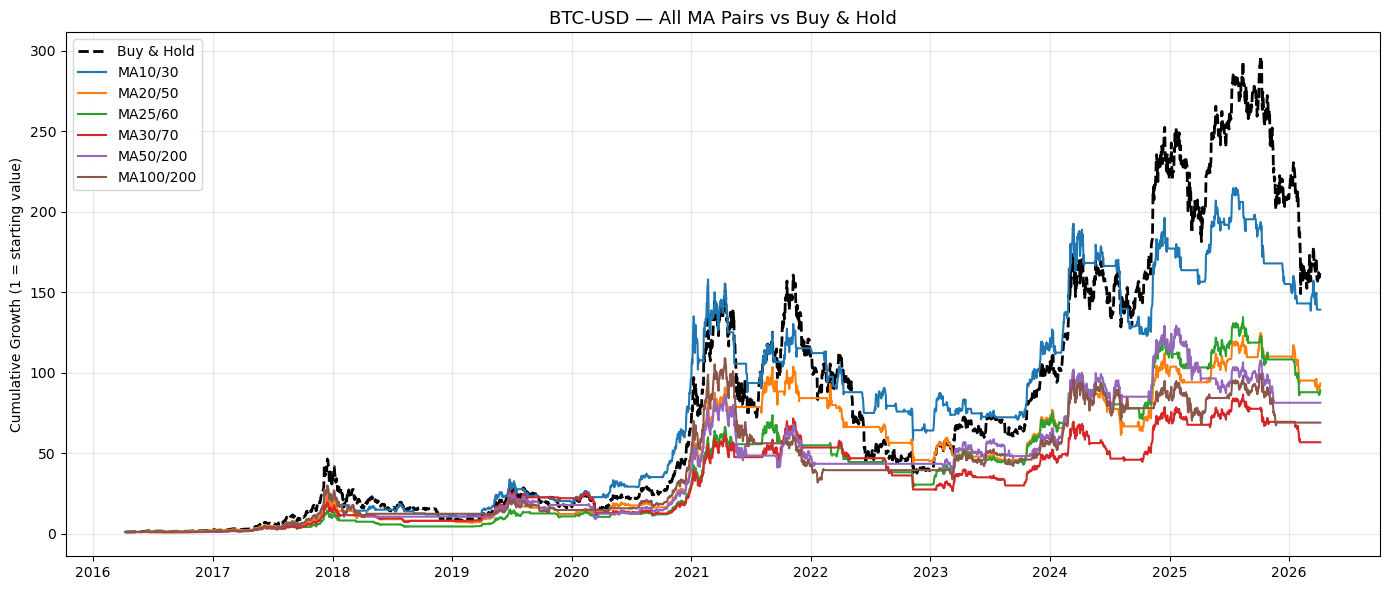

Saved: ma_all_pairs_BTC-USD.png



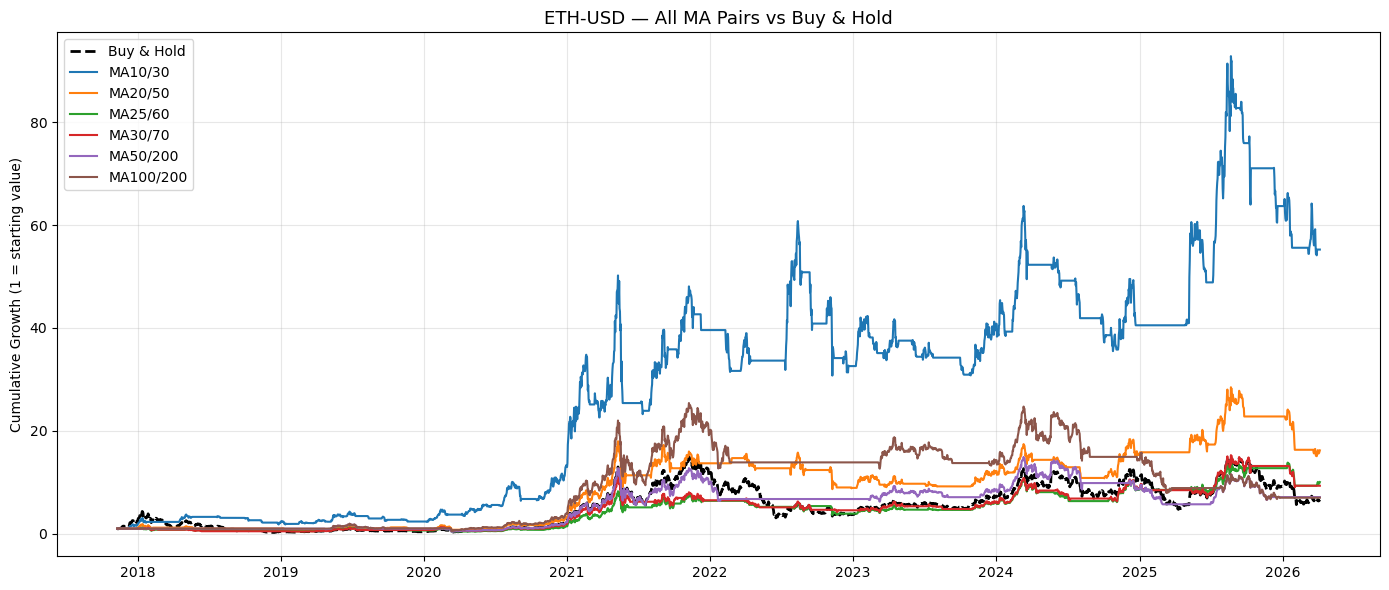

Saved: ma_all_pairs_ETH-USD.png



In [11]:
for stock in stocks:
    print(f"\n{'='*65}")
    print(f"  {stock} — All MA Pairs Compared")
    print(f"{'='*65}")
    print(results_df.loc[stock].to_string())

for stock in stocks:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # plot B&H once (same for all MA pairs)
    first_df = run_backtest(price_data[stock], *ma_pairs[0])
    ax.plot(first_df.index, first_df['cum_market'], 
            color='black', linewidth=2, linestyle='--', label='Buy & Hold')
    
    # plot each MA pair's strategy
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    for (fast, slow), color in zip(ma_pairs, colors):
        df = run_backtest(price_data[stock], fast, slow)
        ax.plot(df.index, df['cum_strategy'], 
                color=color, linewidth=1.5, label=f'MA{fast}/{slow}')
    
    ax.set_title(f"{stock} — All MA Pairs vs Buy & Hold", fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Cumulative Growth (1 = starting value)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'ma_all_pairs_{stock}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: ma_all_pairs_{stock}.png\n")

### import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
endDate   = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * 10)

stocks = ["TSLA", "BTC-USD", "ETH-USD"]

# MA pairs to test: (fast window, slow window)
ma_pairs = [(5, 20), (10, 30), (15, 40), (20, 50), (25, 60), (30, 70)]

# 252 trading days/year for stocks; crypto trades 365 but 252 is fine for comparison
PERIODS_PER_YEAR = 252


# ── Helper: run a single MA crossover backtest ─────────────────────────────────
def run_backtest(price_series, fast, slow):
    df = pd.DataFrame({'price': price_series})
    df[f'MA{fast}'] = df['price'].rolling(window=fast).mean()
    df[f'MA{slow}'] = df['price'].rolling(window=slow).mean()

    # 1 when fast MA is above slow MA, else 0
    df['signal']   = (df[f'MA{fast}'] > df[f'MA{slow}']).astype(int)
    df['position'] = df['signal'].shift(1)          # act the day after signal

    df['log_returns']          = np.log(df['price'] / df['price'].shift(1))
    df['strategy_log_returns'] = df['position'] * df['log_returns']

    df['cum_market']   = np.exp(df['log_returns'].cumsum())
    df['cum_strategy'] = np.exp(df['strategy_log_returns'].cumsum())
    return df


# ── Helper: max drawdown ───────────────────────────────────────────────────────
def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    drawdown    = (cum_series - running_max) / running_max
    return drawdown.min()


# ── Helper: compute all metrics for one backtest run ──────────────────────────
def get_metrics(df):
    market_lr   = df['log_returns'].dropna()
    strategy_lr = df['strategy_log_returns'].dropna()

    total_mkt  = df['cum_market'].dropna().iloc[-1]   - 1
    total_strat = df['cum_strategy'].dropna().iloc[-1] - 1

    ann_mkt    = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat  = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1

    vol_mkt    = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat  = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)

    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan

    mdd_mkt   = max_drawdown(df['cum_market'].dropna())
    mdd_strat = max_drawdown(df['cum_strategy'].dropna())

    # win rate: % of days the strategy had a positive return
    winning_days = (strategy_lr > 0).sum()
    total_days   = (strategy_lr != 0).sum()
    win_rate     = winning_days / total_days if total_days > 0 else np.nan

    return {
        'B&H Total Return %':      round(total_mkt   * 100, 2),
        'Strat Total Return %':    round(total_strat * 100, 2),
        'Strat Annual Return %':   round(ann_strat   * 100, 2),
        'B&H Sharpe':              round(sharpe_mkt,  2),
        'Strat Sharpe':            round(sharpe_strat, 2),
        'B&H Max DD %':            round(mdd_mkt   * 100, 2),
        'Strat Max DD %':          round(mdd_strat * 100, 2),
        'Win Rate %':              round(win_rate   * 100, 2),
    }


# ── Step 1: Download price data (once per ticker) ─────────────────────────────
print("Downloading price data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=startDate, end=endDate, auto_adjust=True, progress=False)
    price_data[stock] = raw['Close'].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Run all MA pair × stock combinations ──────────────────────────────
all_results = []

for fast, slow in ma_pairs:
    for stock in stocks:
        df = run_backtest(price_data[stock], fast, slow)
        metrics = get_metrics(df)
        metrics['Ticker']  = stock
        metrics['MA Pair'] = f"MA{fast}/{slow}"
        all_results.append(metrics)


# ── Step 3: Build the comparison table ────────────────────────────────────────
results_df = (
    pd.DataFrame(all_results)
    .set_index(['Ticker', 'MA Pair'])
    .sort_index()
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

print("\n" + "=" * 100)
print("  MA CROSSOVER STRATEGY — FULL COMPARISON TABLE")
print("=" * 100)
print(results_df.to_string())


# ── Step 4: Best MA pair per stock (by Strategy Sharpe) ───────────────────────
reset = results_df.reset_index()
best_idx = reset.groupby('Ticker')['Strat Sharpe'].idxmax()
best = reset.loc[best_idx, ['Ticker', 'MA Pair', 'Strat Sharpe',
                              'Strat Total Return %', 'Strat Max DD %', 'Win Rate %']]
best = best.set_index('Ticker')

print("\n" + "=" * 100)
print("  BEST MA PAIR PER TICKER  (ranked by Strategy Sharpe Ratio)")
print("=" * 100)
print(best.to_string())


# ── Step 5: Equity curves — best MA pair per stock ────────────────────────────
best_pairs = best['MA Pair'].to_dict()   # e.g. {'AAPL': 'MA10/30', ...}

n_stocks = len(stocks)
cols = 3
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax = axes[i]
    fast_str, slow_str = best_pairs[stock].replace('MA', '').split('/')
    fast, slow = int(fast_str), int(slow_str)

    df = run_backtest(price_data[stock], fast, slow)
    df[['cum_market', 'cum_strategy']].plot(ax=ax)

    ax.set_title(f"{stock}  |  Best pair: {best_pairs[stock]}", fontsize=12)
    ax.set_xlabel('')
    ax.legend(['Buy & Hold', f"MA{fast}/{slow} Strategy"])
    ax.grid(True, alpha=0.3)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Equity Curves — Best MA Pair per Ticker", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('ma_best_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as 'ma_best_equity_curves.png'")


# ── Step 6: Strategy Sharpe heatmap (MA pair vs Ticker) ───────────────────────
sharpe_pivot = reset.pivot(index='MA Pair', columns='Ticker', values='Strat Sharpe')

fig2, ax2 = plt.subplots(figsize=(12, 5))
im = ax2.imshow(sharpe_pivot.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax2, label='Strategy Sharpe Ratio')

ax2.set_xticks(range(len(sharpe_pivot.columns)))
ax2.set_xticklabels(sharpe_pivot.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(sharpe_pivot.index)))
ax2.set_yticklabels(sharpe_pivot.index)
ax2.set_title("Strategy Sharpe Ratio Heatmap — MA Pair vs Ticker", fontsize=13)

# annotate cells
for row_i in range(len(sharpe_pivot.index)):
    for col_j in range(len(sharpe_pivot.columns)):
        val = sharpe_pivot.values[row_i, col_j]
        ax2.text(col_j, row_i, f"{val:.2f}", ha='center', va='center',
                 fontsize=10, color='black')

plt.tight_layout()
plt.savefig('ma_sharpe_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved as 'ma_sharpe_heatmap.png'")


  BTC-USD: 3749 rows
  ETH-USD: 3071 rows
  TSLA: 2577 rows

  In-sample  period: 2016-01-01 → 2021-01-01
  Out-of-sample period: 2021-01-01 → 2026-04-06

  STEP 1 — TRAINING (In-Sample: 2016–2020)
  Finding best MA pair per stock on training data only...
  BTC-USD: best in-sample pair = MA10/30 (Sharpe: 2.03)
  ETH-USD: best in-sample pair = MA10/30 (Sharpe: 1.38)
  TSLA: best in-sample pair = MA5/20 (Sharpe: 1.33)

Full in-sample results:
                 B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  Strat Max DD %
Ticker  MA Pair                                                                                                           
BTC-USD MA5/20              6577.29               8580.44                  85.15        1.25          1.95          -66.70
        MA10/30             6577.29              10717.30                  90.86        1.25          2.03          -55.78
        MA15/40             6577.29               7053.40     

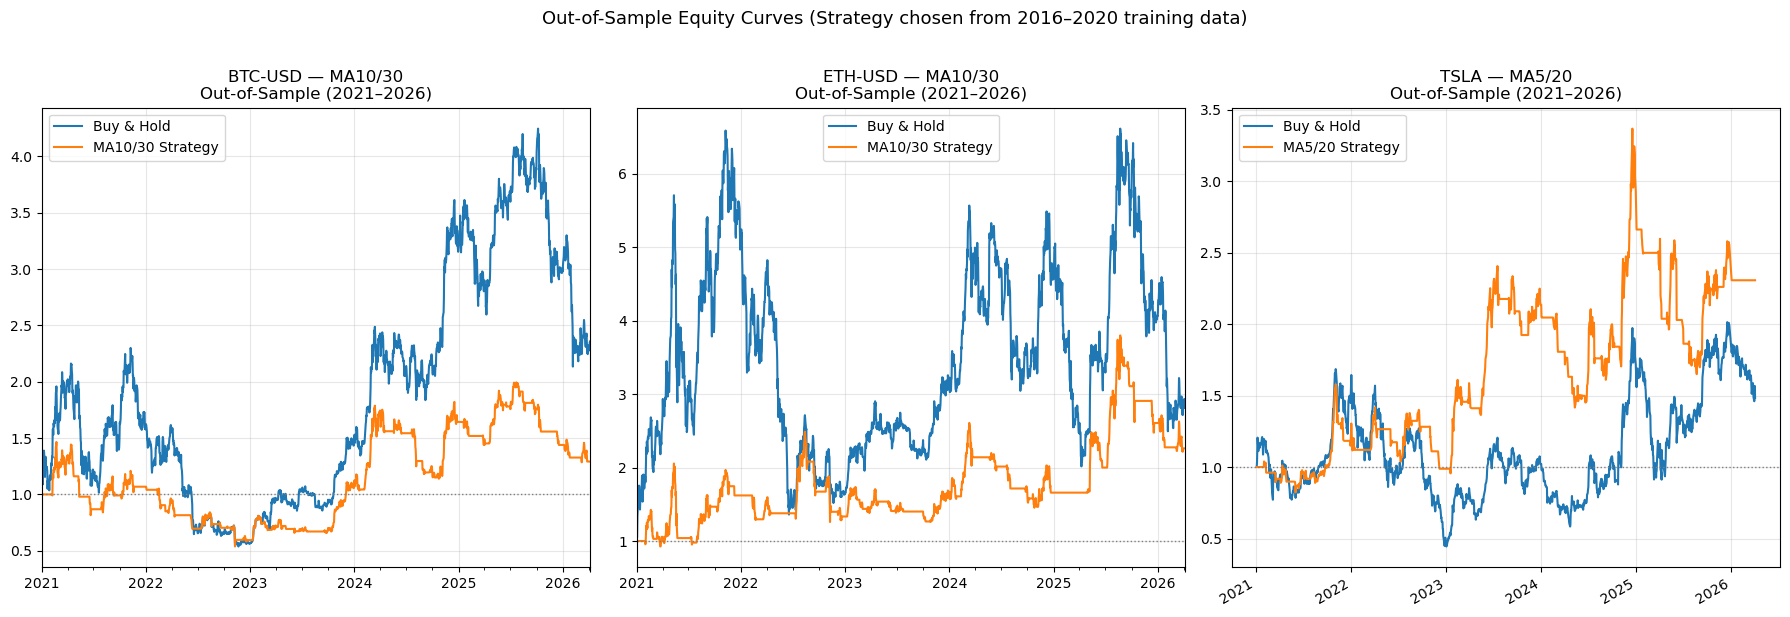


Chart saved as 'out_of_sample_equity_curves.png'


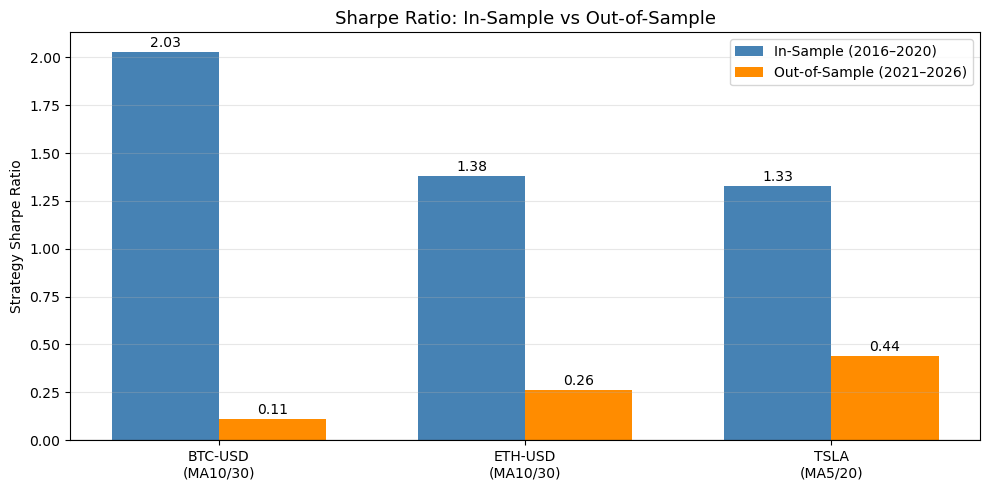

Chart saved as 'sharpe_in_vs_out.png'


In [15]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
FULL_START   = dt.datetime(2016, 1, 1)
SPLIT_DATE   = dt.datetime(2021, 1, 1)   # train = before this, test = after this
FULL_END     = dt.datetime.now()

stocks   = ["BTC-USD", "ETH-USD", "TSLA"]
ma_pairs = [(5, 20), (10, 30), (15, 40), (20, 50), (25, 60), (30, 70)]

PERIODS_PER_YEAR = 252


# ── Helpers ────────────────────────────────────────────────────────────────────
def run_backtest(price_series, fast, slow):
    df = pd.DataFrame({'price': price_series})
    df[f'MA{fast}'] = df['price'].rolling(window=fast).mean()
    df[f'MA{slow}'] = df['price'].rolling(window=slow).mean()
    df['signal']   = (df[f'MA{fast}'] > df[f'MA{slow}']).astype(int)
    df['position'] = df['signal'].shift(1)
    df['log_returns']          = np.log(df['price'] / df['price'].shift(1))
    df['strategy_log_returns'] = df['position'] * df['log_returns']
    df['cum_market']   = np.exp(df['log_returns'].cumsum())
    df['cum_strategy'] = np.exp(df['strategy_log_returns'].cumsum())
    return df

def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    return ((cum_series - running_max) / running_max).min()

def get_metrics(df):
    market_lr   = df['log_returns'].dropna()
    strategy_lr = df['strategy_log_returns'].dropna()
    total_mkt    = df['cum_market'].dropna().iloc[-1]   - 1
    total_strat  = df['cum_strategy'].dropna().iloc[-1] - 1
    ann_mkt      = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat    = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1
    vol_mkt      = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat    = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)
    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan
    mdd_strat    = max_drawdown(df['cum_strategy'].dropna())
    return {
        'B&H Total Return %':    round(total_mkt   * 100, 2),
        'Strat Total Return %':  round(total_strat * 100, 2),
        'Strat Annual Return %': round(ann_strat   * 100, 2),
        'B&H Sharpe':            round(sharpe_mkt,   2),
        'Strat Sharpe':          round(sharpe_strat, 2),
        'Strat Max DD %':        round(mdd_strat   * 100, 2),
    }


# ── Step 1: Download full price data ──────────────────────────────────────────
print("Downloading data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=FULL_START, end=FULL_END,
                      auto_adjust=True, progress=False)
    price_data[stock] = raw['Close'].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Split into in-sample and out-of-sample ────────────────────────────
in_sample  = {s: price_data[s][price_data[s].index < SPLIT_DATE]  for s in stocks}
out_sample = {s: price_data[s][price_data[s].index >= SPLIT_DATE] for s in stocks}

print(f"\n  In-sample  period: {FULL_START.date()} → {SPLIT_DATE.date()}")
print(f"  Out-of-sample period: {SPLIT_DATE.date()} → {FULL_END.date()}\n")


# ── Step 3: Find best MA pair per stock using IN-SAMPLE data ONLY ─────────────
print("=" * 70)
print("  STEP 1 — TRAINING (In-Sample: 2016–2020)")
print("  Finding best MA pair per stock on training data only...")
print("=" * 70)

best_pairs = {}   # stores chosen MA pair for each stock
in_sample_results = []

for stock in stocks:
    best_sharpe = -999
    best_pair   = None
    for fast, slow in ma_pairs:
        df      = run_backtest(in_sample[stock], fast, slow)
        metrics = get_metrics(df)
        metrics['Ticker']  = stock
        metrics['MA Pair'] = f"MA{fast}/{slow}"
        in_sample_results.append(metrics)
        if metrics['Strat Sharpe'] > best_sharpe:
            best_sharpe = metrics['Strat Sharpe']
            best_pair   = (fast, slow)
    best_pairs[stock] = best_pair
    print(f"  {stock}: best in-sample pair = MA{best_pair[0]}/{best_pair[1]} "
          f"(Sharpe: {best_sharpe:.2f})")

in_sample_df = pd.DataFrame(in_sample_results).set_index(['Ticker', 'MA Pair'])
print("\nFull in-sample results:")
print(in_sample_df.to_string())


# ── Step 4: Apply chosen pairs to OUT-OF-SAMPLE data ─────────────────────────
print("\n" + "=" * 70)
print("  STEP 2 — TESTING (Out-of-Sample: 2021–2026)")
print("  Applying the pairs chosen from training data to unseen data...")
print("=" * 70)

oos_results = []
oos_data    = {}   # store dataframes for plotting

for stock in stocks:
    fast, slow = best_pairs[stock]
    df         = run_backtest(out_sample[stock], fast, slow)
    metrics    = get_metrics(df)
    metrics['Ticker']  = stock
    metrics['MA Pair'] = f"MA{fast}/{slow}"
    oos_results.append(metrics)
    oos_data[stock] = df
    print(f"\n  {stock} — MA{fast}/{slow} on out-of-sample data:")
    for k, v in metrics.items():
        if k not in ['Ticker', 'MA Pair']:
            print(f"    {k}: {v}")

oos_df = pd.DataFrame(oos_results).set_index('Ticker')


# ── Step 5: Side-by-side comparison table ────────────────────────────────────
print("\n" + "=" * 70)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

rows = []
for stock in stocks:
    fast, slow  = best_pairs[stock]
    pair_label  = f"MA{fast}/{slow}"
    in_s  = in_sample_df.loc[(stock, pair_label)]
    out_s = oos_df.loc[stock]
    rows.append({
        'Ticker':              stock,
        'Best Pair':           pair_label,
        'IN Strat Return %':   in_s['Strat Total Return %'],
        'OUT Strat Return %':  out_s['Strat Total Return %'],
        'IN B&H Return %':     in_s['B&H Total Return %'],
        'OUT B&H Return %':    out_s['B&H Total Return %'],
        'IN Sharpe':           in_s['Strat Sharpe'],
        'OUT Sharpe':          out_s['Strat Sharpe'],
        'IN Max DD %':         in_s['Strat Max DD %'],
        'OUT Max DD %':        out_s['Strat Max DD %'],
    })

comparison = pd.DataFrame(rows).set_index('Ticker')
print(comparison.to_string())

# Key verdict
print("\n  VERDICT:")
for stock in stocks:
    in_sharpe  = comparison.loc[stock, 'IN Sharpe']
    out_sharpe = comparison.loc[stock, 'OUT Sharpe']
    drop       = ((out_sharpe - in_sharpe) / in_sharpe) * 100
    in_ret     = comparison.loc[stock, 'IN Strat Return %']
    out_ret    = comparison.loc[stock, 'OUT Strat Return %']
    beats_bah  = out_ret > comparison.loc[stock, 'OUT B&H Return %']
    print(f"  {stock}: Sharpe changed {in_sharpe:.2f} → {out_sharpe:.2f} "
          f"({drop:+.1f}%)  |  Beats B&H out-of-sample: {beats_bah}")


# ── Step 6: Out-of-sample equity curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, stock in enumerate(stocks):
    ax         = axes[i]
    fast, slow = best_pairs[stock]
    df         = oos_data[stock]

    df[['cum_market', 'cum_strategy']].plot(ax=ax)
    ax.set_title(f"{stock} — MA{fast}/{slow}\nOut-of-Sample (2021–2026)", fontsize=12)
    ax.legend(['Buy & Hold', f"MA{fast}/{slow} Strategy"])
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color='gray', linestyle=':', linewidth=1)  # break-even line

plt.suptitle("Out-of-Sample Equity Curves (Strategy chosen from 2016–2020 training data)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('out_of_sample_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as 'out_of_sample_equity_curves.png'")


# ── Step 7: In-sample vs Out-of-sample Sharpe bar chart ──────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))

x      = np.arange(len(stocks))
width  = 0.35
in_sh  = [comparison.loc[s, 'IN Sharpe']  for s in stocks]
out_sh = [comparison.loc[s, 'OUT Sharpe'] for s in stocks]

bars1 = ax2.bar(x - width/2, in_sh,  width, label='In-Sample (2016–2020)',  color='steelblue')
bars2 = ax2.bar(x + width/2, out_sh, width, label='Out-of-Sample (2021–2026)', color='darkorange')

ax2.set_xticks(x)
ax2.set_xticklabels([f"{s}\n({comparison.loc[s,'Best Pair']})" for s in stocks])
ax2.set_ylabel('Strategy Sharpe Ratio')
ax2.set_title('Sharpe Ratio: In-Sample vs Out-of-Sample', fontsize=13)
ax2.legend()
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

# label bars
for bar in bars1 + bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('sharpe_in_vs_out.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'sharpe_in_vs_out.png'")